<a href="https://colab.research.google.com/github/JoeyyZhang/ER131/blob/main/Cleaning_merging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import style
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# read files of PSPS events
SDGE_df = pd.read_csv('/content/drive/MyDrive/er131data/SDGEPOSTSR2B332025Template.csv',skiprows=3)

#Chris content/drive/MyDrive/SDGEPOSTSR2B332025Template.csv
#Sol /content/drive/MyDrive/Fall 2025/4. ENERES 131: Data, Environment & Society (Callaway)/ENERES 131 Group Project
SDGE_df.columns

Index(['EVENTID', 'EVENTPERIOD', 'MeterID', 'TractID',
       '\nTotal number of customer accounts de-energized',
       'Median amount of time de-energized (minutes)',
       'Maximum amount of time de-energized (minutes)',
       'Total number of non-CARE/FERA customer accounts de-energized',
       'Median amount of time de-energized',
       'Maximum amount of time de-energized',
       'Total number of CARE/FERA customer accounts de-energized',
       'Median amount of time de-energized.1',
       'Maximum amount of time de-energized.1',
       'Total number of MBL customer accounts de-energized',
       'Median amount of time de-energized.2',
       'Maximum amount of time de-energized.2',
       'Total number of customers who self-identified for advance notification that were de-energized',
       'Median amount of time de-energized.3',
       'Maximum amount of time de-energized.3'],
      dtype='object')

In [4]:
PGE_df = gpd.read_file('/content/drive/MyDrive/er131data/PGE_POSTR2A_2025.gdb')
PGE_df.columns

Index(['TRACT', 'Tract_1', 'YYYYMM', 'MaxEvents', 'MaxHours', 'MinHours',
       'MedHours', 'TotCustomer', 'TotHours', 'TotCARE_Customer',
       'TotCARE_Hours', 'TotMBL_Customer', 'TotMBL_Hours',
       'TotSelfID_Customer', 'TotSelfID_Hours', 'TRACT2', 'SHAPE_Length',
       'SHAPE_Area', 'geometry'],
      dtype='object')

In [5]:
SCE_df = gpd.read_file('/content/drive/MyDrive/er131data/SCE_POSTSR2A51_2025.gdb/SCE_POSTSR2A_5-1-2025.gdb/SCE_POSTSR2A_5-1-2025.gdb')
SCE_df.columns

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'SCE_POSTSR2A_5-1-2025.gdb': 'SCE_POSTSR2A_5_1_2025' (default), 'CES_FINAL'. Specify layer parameter to avoid this warning.
  result = read_func(


Index(['YYYYMM', 'Track', 'MaxEvents', 'MaxHours', 'MinHours', 'MedHours',
       'TotCustomer', 'TotHours', 'TotCARE_Customer', 'TotCARE_Hours',
       'TotMBL_Customer', 'TotMBL_Hours', 'TotSelfID_Customer',
       'TotSelfID_Hours', 'Shape_Length', 'Shape_Area', 'geometry'],
      dtype='object')

In [6]:
PGE_df_2023 = gpd.read_file('/content/drive/MyDrive/er131data/PGE_POSTR2A_2023.gdb/PGE_POSTR2A.2023.gdb')
PGE_df_2023.head()

,Tract,YYYYMM,MaxEvents,MaxHours,MinHours,MedHours,TotCustomer,TotHours,TotCARE_Customer,TotCARE_Hours,TotMBL_Customer,TotMBL_Hours,TotSelfID_Customer,TotSelfID_Hours,SHAPE_Length,SHAPE_Area,geometry
0,6.007002e+09,202308,1.0,16.830000,16.02,16.030001,349,5687.330078,2,32.669998,23,375.730011,3,48.049999,200720.367583,1.151430e+09,"MULTIPOLYGON (((633158.576 4420099.167, 633232..."
1,6.011000e+09,202308,1.0,30.370001,13.78,13.780000,22,435.899994,0,NaN,0,0.000000,0,0.000000,162356.107086,9.522709e+08,"MULTIPOLYGON (((557687.65 4351110.04, 558040.0..."
2,6.011000e+09,202308,1.0,30.370001,13.78,15.220000,478,8726.679688,7,104.830002,38,667.799988,11,197.779999,218645.408354,1.082519e+09,"MULTIPOLYGON (((574363.494 4363131.567, 575230..."
3,6.021010e+09,202308,1.0,16.430000,13.07,15.320000,392,6133.220215,3,45.970001,19,301.070007,8,125.680000,262403.178512,2.562644e+09,"MULTIPOLYGON (((508410.526 4405483.232, 509092..."
4,6.023010e+09,202308,1.0,15.150000,15.15,15.150000,1,15.150000,0,0.000000,0,0.000000,0,0.000000,168657.954062,6.493906e+08,"MULTIPOLYGON (((424370.174 4548886.485, 424439..."


In [7]:
# clean the columns
columns_to_drop1 = [SDGE_df.columns[0]] + list(SDGE_df.columns[7:19])
SDGE_trim = SDGE_df.drop(columns=columns_to_drop1)
SDGE_trim

,EVENTPERIOD,MeterID,TractID,\nTotal number of customer accounts de-energized,Median amount of time de-energized (minutes),Maximum amount of time de-energized (minutes)
0,"Dec 9-11, 2024",6458893,6.065043e+09,1,2905,2905
1,"Dec 9-11, 2024",6290934,6.065043e+09,2,2905,2905
2,"Dec 9-11, 2024",6457378,6.065043e+09,2,2905,2905
3,"Dec 9-11, 2024",6823175,6.065044e+09,35,2885,2936
4,"Dec 9-11, 2024",6485058,6.065044e+09,35,2885,2936
...,...,...,...,...,...,...
53429,"Dec 9-11, 2024",50001788,NaN,4,2208,2692
53430,"Dec 9-11, 2024",6460190,NaN,4,2208,2692
53431,"Dec 9-11, 2024",6474295,NaN,4,2208,2692
53432,"Dec 9-11, 2024",6289217,NaN,4,2208,2692


In [8]:
columns_to_drop2 = [PGE_df.columns[0]] + list(PGE_df.columns[9:17])
PGE_trim = PGE_df.drop(columns=columns_to_drop2)
PGE_trim.rename(columns={'Tract_1': 'Tract'}, inplace=True)
PGE_trim

,Tract,YYYYMM,MaxEvents,MaxHours,MinHours,MedHours,TotCustomer,TotHours,SHAPE_Area,geometry
0,6.011000e+09,202407,1,25.516667,25.516667,25.516667,5,127.583333,9.522610e+08,"MULTIPOLYGON (((578889.07 4323489.39, 578295.8..."
1,6.011000e+09,202407,1,25.566667,25.516667,25.516667,15,382.900000,5.670325e+08,"MULTIPOLYGON (((591946.5 4330104.99, 591943.6 ..."
2,6.103001e+09,202407,1,28.483333,28.483333,28.483333,1,28.483333,2.751068e+08,"MULTIPOLYGON (((596303.21 4415488.81, 596100.4..."
3,6.103000e+09,202407,1,30.950000,27.233333,28.483333,1047,30201.216670,3.332060e+09,"MULTIPOLYGON (((502615.89 4443211.36, 502392.6..."
4,6.097154e+09,202407,1,40.283333,29.166667,29.166667,34,1049.266667,5.797217e+08,"MULTIPOLYGON (((519422.44 4297177.53, 519439.9..."
...,...,...,...,...,...,...,...,...,...,...
294,6.095253e+09,202411,1,43.116667,43.116667,43.116667,106,4570.366667,3.581507e+06,"MULTIPOLYGON (((589481.55 4251239.12, 589567.9..."
295,6.095252e+09,202411,1,43.166667,26.650000,27.033333,425,11749.866670,9.351186e+07,"MULTIPOLYGON (((572428.72 4241185.75, 572665.9..."
296,6.029005e+09,202412,1,20.116667,20.116667,20.116667,5,100.583333,9.460976e+08,"MULTIPOLYGON (((916813.64 3926618.4, 916819.59..."
297,6.029006e+09,202412,1,22.983333,20.916667,20.966667,54,1174.350000,1.770111e+09,"MULTIPOLYGON (((872643.54 3869493.11, 872633.9..."


In [9]:
columns_to_drop3 = list(SCE_df.columns[8:15])
SCE_trim = SCE_df.drop(columns=columns_to_drop3)
SCE_trim

,YYYYMM,Track,MaxEvents,MaxHours,MinHours,MedHours,TotCustomer,TotHours,Shape_Area,geometry
0,202411,6.083003e+09,1.0,18.400000,18.400000,18.400000,10,184.000000,1.789782e+07,"MULTIPOLYGON Z (((-13330442.188 4087273.114 0,..."
1,202409,6.083003e+09,1.0,16.969999,16.969999,16.969999,194,3292.179932,3.422523e+08,"MULTIPOLYGON Z (((-13363760.435 4101027.657 0,..."
2,202412,6.083002e+09,1.0,32.169998,32.169998,32.169998,1,32.169998,1.796631e+08,"MULTIPOLYGON Z (((-13304289.546 4095374.109 0,..."
3,202411,6.083002e+09,2.0,35.980000,18.400000,18.400000,2,54.380001,1.796631e+08,"MULTIPOLYGON Z (((-13304289.546 4095374.109 0,..."
4,202411,6.083000e+09,1.0,18.400000,18.400000,18.400000,1,18.400000,3.013734e+06,"MULTIPOLYGON Z (((-13326248.877 4088082.33 0, ..."
...,...,...,...,...,...,...,...,...,...,...
908,202411,6.037911e+09,1.0,49.919998,33.700001,49.919998,62,3078.820068,3.515139e+07,"MULTIPOLYGON Z (((-13172466.653 4093051.617 0,..."
909,202412,6.037911e+09,2.0,44.450001,25.080000,25.080000,149,4918.490234,3.515139e+07,"MULTIPOLYGON Z (((-13172466.653 4093051.617 0,..."
910,202409,6.037920e+09,1.0,16.969999,16.969999,16.969999,1,16.969999,1.793198e+06,"MULTIPOLYGON Z (((-13188246.432 4085828.513 0,..."
911,202411,6.037481e+09,1.0,49.770000,49.770000,49.770000,1,49.770000,2.676418e+06,"MULTIPOLYGON Z (((-13145484.247 4039587.558 0,..."


In [10]:
columns_to_drop3 = list(PGE_df_2023.columns[8:15])
PGE_2023_trim = PGE_df_2023.drop(columns=columns_to_drop3)
PGE_2023_trim

,Tract,YYYYMM,MaxEvents,MaxHours,MinHours,MedHours,TotCustomer,TotHours,SHAPE_Area,geometry
0,6.007002e+09,202308,1.0,16.830000,16.020000,16.030001,349,5687.330078,1.151430e+09,"MULTIPOLYGON (((633158.576 4420099.167, 633232..."
1,6.011000e+09,202308,1.0,30.370001,13.780000,13.780000,22,435.899994,9.522709e+08,"MULTIPOLYGON (((557687.65 4351110.04, 558040.0..."
2,6.011000e+09,202308,1.0,30.370001,13.780000,15.220000,478,8726.679688,1.082519e+09,"MULTIPOLYGON (((574363.494 4363131.567, 575230..."
3,6.021010e+09,202308,1.0,16.430000,13.070000,15.320000,392,6133.220215,2.562644e+09,"MULTIPOLYGON (((508410.526 4405483.232, 509092..."
4,6.023010e+09,202308,1.0,15.150000,15.150000,15.150000,1,15.150000,6.493906e+08,"MULTIPOLYGON (((424370.174 4548886.485, 424439..."
5,6.033001e+09,202308,1.0,30.370001,30.370001,30.370001,1,30.370001,3.250294e+08,"MULTIPOLYGON (((540178.579 4340271.312, 540245..."
6,6.033001e+09,202308,1.0,11.420000,11.420000,11.420000,50,570.830017,3.743278e+08,"MULTIPOLYGON (((545130.453 4315256.553, 545070..."
7,6.035040e+09,202308,1.0,32.919998,32.919998,32.919998,1,32.919998,7.606000e+09,"MULTIPOLYGON (((643568.557 4560571.838, 646421..."
8,6.089011e+09,202308,1.0,16.700001,16.700001,16.700001,34,567.799988,4.586074e+07,"MULTIPOLYGON (((547452.011 4489617.219, 547509..."
9,6.089012e+09,202308,1.0,17.129999,16.700001,17.129999,48,821.969971,9.514762e+07,"MULTIPOLYGON (((540729.257 4484502.812, 540886..."


In [11]:
# Concatenate two years data of PGE
PGE_combined = pd.concat([PGE_trim, PGE_2023_trim], ignore_index=True)
# clean datatype
PGE_combined['YYYYMM'] = pd.to_numeric(PGE_combined['YYYYMM'], errors='coerce')
PGE_combined.dropna(subset=['YYYYMM'], inplace=True)
PGE_combined['YYYYMM'] = PGE_combined['YYYYMM'].astype(int)
PGE_combined = PGE_combined.sort_values(by='YYYYMM', ascending=False)
PGE_combined

,Tract,YYYYMM,MaxEvents,MaxHours,MinHours,MedHours,TotCustomer,TotHours,SHAPE_Area,geometry
298,6.029003e+09,202412,1.0,22.983333,20.916667,22.983333,512,11662.566670,1.076427e+09,"MULTIPOLYGON (((856704.37 3859231.64, 856692.6..."
297,6.029006e+09,202412,1.0,22.983333,20.916667,20.966667,54,1174.350000,1.770111e+09,"MULTIPOLYGON (((872643.54 3869493.11, 872633.9..."
296,6.029005e+09,202412,1.0,20.116667,20.116667,20.116667,5,100.583333,9.460976e+08,"MULTIPOLYGON (((916813.64 3926618.4, 916819.59..."
295,6.095252e+09,202411,1.0,43.166667,26.650000,27.033333,425,11749.866670,9.351186e+07,"MULTIPOLYGON (((572428.72 4241185.75, 572665.9..."
294,6.095253e+09,202411,1.0,43.116667,43.116667,43.116667,106,4570.366667,3.581507e+06,"MULTIPOLYGON (((589481.55 4251239.12, 589567.9..."
...,...,...,...,...,...,...,...,...,...,...
299,6.007002e+09,202308,1.0,16.830000,16.020000,16.030001,349,5687.330078,1.151430e+09,"MULTIPOLYGON (((633158.576 4420099.167, 633232..."
302,6.021010e+09,202308,1.0,16.430000,13.070000,15.320000,392,6133.220215,2.562644e+09,"MULTIPOLYGON (((508410.526 4405483.232, 509092..."
301,6.011000e+09,202308,1.0,30.370001,13.780000,15.220000,478,8726.679688,1.082519e+09,"MULTIPOLYGON (((574363.494 4363131.567, 575230..."
300,6.011000e+09,202308,1.0,30.370001,13.780000,13.780000,22,435.899994,9.522709e+08,"MULTIPOLYGON (((557687.65 4351110.04, 558040.0..."


In [12]:
# initial visualization
PGE_tracts = PGE_combined.groupby('Tract').agg({'MaxEvents': 'sum'}).sort_values(by='MaxEvents', ascending=False)
PGE_tracts

,MaxEvents
Tract,
6.103000e+09,6.0
6.011000e+09,5.0
6.007002e+09,5.0
6.023010e+09,5.0
6.033001e+09,5.0
...,...
6.103000e+09,1.0
6.103000e+09,1.0
6.103000e+09,1.0


<Axes: >

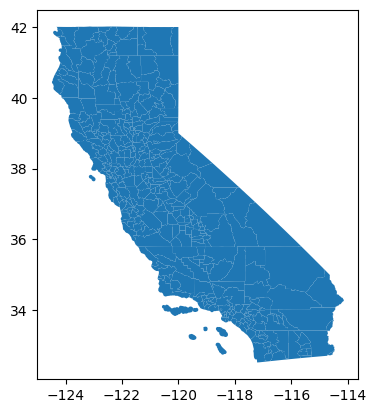

In [15]:
Counties_df = gpd.read_file('/content/drive/MyDrive/er131data/tl_2024_06_cousub/tl_2024_06_cousub.shp')
Counties_df.plot()

In [16]:
PGE_combined = PGE_combined.to_crs(Counties_df.crs)

# Perform the spatial join, keeping all columns from PGE_combined
PGE_combined = gpd.sjoin(
    PGE_combined,
    Counties_df[['NAME', 'geometry']],
    how='left',
    predicate='intersects'
)

PGE_combined = PGE_combined.rename(columns={'NAME': 'County'})

PGE_combined = PGE_combined.drop(columns='index_right')

PGE_combined

,Tract,YYYYMM,MaxEvents,MaxHours,MinHours,MedHours,TotCustomer,TotHours,SHAPE_Area,geometry,County
298,6.029003e+09,202412,1.0,22.983333,20.916667,22.983333,512,11662.566670,1.076427e+09,"MULTIPOLYGON (((-119.10089 34.81291, -119.1010...",Los Padres
298,6.029003e+09,202412,1.0,22.983333,20.916667,22.983333,512,11662.566670,1.076427e+09,"MULTIPOLYGON (((-119.10089 34.81291, -119.1010...",North Antelope Valley
298,6.029003e+09,202412,1.0,22.983333,20.916667,22.983333,512,11662.566670,1.076427e+09,"MULTIPOLYGON (((-119.10089 34.81291, -119.1010...",Tehachapi
298,6.029003e+09,202412,1.0,22.983333,20.916667,22.983333,512,11662.566670,1.076427e+09,"MULTIPOLYGON (((-119.10089 34.81291, -119.1010...",Arvin-Lamont
298,6.029003e+09,202412,1.0,22.983333,20.916667,22.983333,512,11662.566670,1.076427e+09,"MULTIPOLYGON (((-119.10089 34.81291, -119.1010...",Cuyama
...,...,...,...,...,...,...,...,...,...,...,...
300,6.011000e+09,202308,1.0,30.370001,13.780000,13.780000,22,435.899994,9.522709e+08,"MULTIPOLYGON (((-122.33089 39.30746, -122.3268...",Central Colusa
300,6.011000e+09,202308,1.0,30.370001,13.780000,13.780000,22,435.899994,9.522709e+08,"MULTIPOLYGON (((-122.33089 39.30746, -122.3268...",East Colusa
303,6.023010e+09,202308,1.0,15.150000,15.150000,15.150000,1,15.150000,6.493906e+08,"MULTIPOLYGON (((-123.90046 41.08773, -123.8996...",Arcata
303,6.023010e+09,202308,1.0,15.150000,15.150000,15.150000,1,15.150000,6.493906e+08,"MULTIPOLYGON (((-123.90046 41.08773, -123.8996...",Willow Creek-Hoopa Valley


In [22]:
events_by_county = PGE_combined.groupby(['County','YYYYMM'])['MaxEvents'].sum().sort_values(ascending=False)
events_by_county

County                YYYYMM
Central Contra Costa  202411    26.0
Redding               202409    19.0
Napa                  202411    18.0
San Jose              202411    15.0
Napa                  202410    15.0
                                ... 
West Tehama           202407     1.0
Westport              202410     1.0
                      202411     1.0
Alameda               202411     1.0
Arcata                202407     1.0
Name: MaxEvents, Length: 434, dtype: float64

<Axes: >

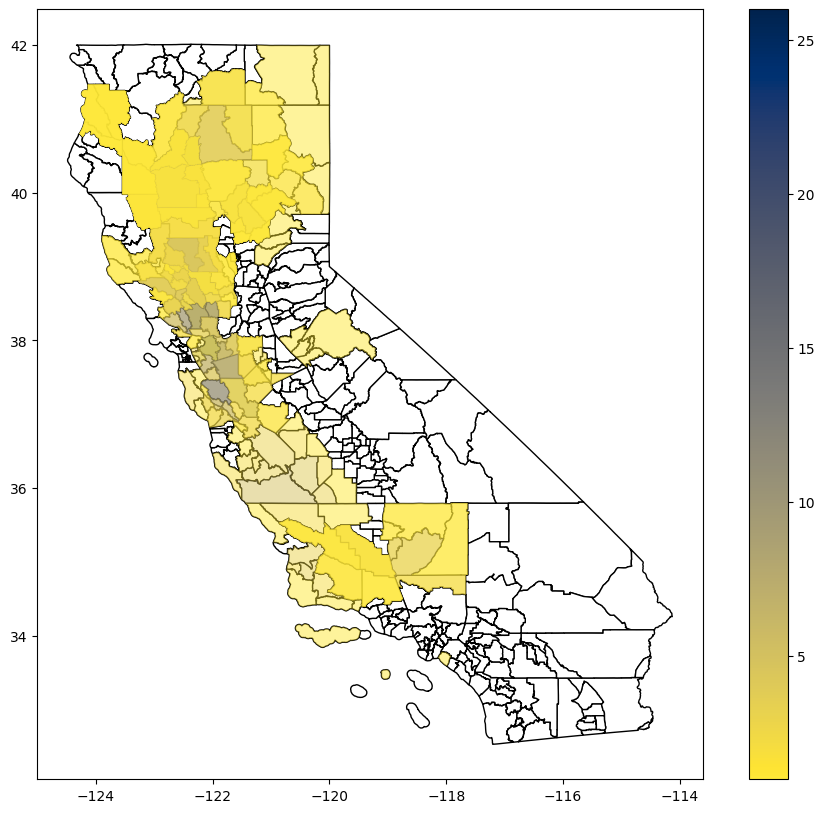

In [23]:
Counties_with_counts = Counties_df.merge(
    events_by_county,
    left_on='NAME',
    right_on='County',
    how='inner'
)

fig3, ax3 = plt.subplots(figsize=(12, 10))
Counties_df.plot(ax=ax3, color = 'white', edgecolor='black')
Counties_with_counts.plot(column='MaxEvents',ax=ax3, cmap = 'cividis_r', legend=True, alpha = 0.5)

In [ ]:
climate = pd.read_csv('/content/drive/MyDrive/GIS Data PSPS/CA_Daymet_tmax_2024_daily_byCounty.csv')
maxtemp = climate.rename(columns={"NAME": "County",
"date": "Date",
"mean":"average high temperature"})
maxtemp = maxtemp.loc[:,["County","Date","GEOID","average high temperature"]]
maxtemp['Date'] = pd.to_datetime(maxtemp['Date'])
monthly_avg_maxtemp = maxtemp.groupby(['County', 'GEOID', maxtemp['Date'].dt.to_period('M')])['average high temperature'].mean().reset_index()
monthly_avg_maxtemp.rename(columns={'Date': 'Month'}, inplace=True)
monthly_avg_maxtemp['Month'] = monthly_avg_maxtemp['Month'].astype(str)
display(monthly_avg_maxtemp)